# BCemu Parameter Impact on S(k)

Baryonic suppression $S(k,z) = P_{\rm dmb}(k,z)/P_{\rm dmo}(k,z)$ as each
baryonification parameter is varied across its range, with all other
parameters held at their fiducial values.

**Layout per model:** columns are $z = 0, 1, 2$; rows are the individual
parameters. Line colour encodes the parameter value (colourbar on the right);
the black dashed line is the fiducial model.

**Models:** 1. BCemu2021 (`BCM_7param`) — 2. BCemu2025

**Requires:** `pip install smt==1.0.0` for BCemu2021.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import BCemu

%matplotlib inline
plt.rcParams.update({
    'font.size': 11, 'axes.labelsize': 12, 'legend.fontsize': 9,
    'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3,
})

Ob, Om   = 0.0486, 0.306
z_arr    = np.array([0.0, 1.0, 2.0])
Z_LABELS = [r'$z = 0$', r'$z = 1$', r'$z = 2$']
N_CURVES = 9    # number of lines per parameter sweep

/Users/sgiri/miniforge3/envs/bcemu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def plot_param_sweep(Sk_func, fiducial, param_ranges, param_latex, k,
                     cmap_name, title, ylim=None):
    '''
    Grid of S(k) panels: rows = parameters, columns = redshifts.

    Sk_func(params, z) -> S(k) evaluated on the array `k`.
    '''
    pnames   = list(param_ranges.keys())
    n_params = len(pnames)
    cmap     = plt.get_cmap(cmap_name)

    Sk_fid = [Sk_func(fiducial, z) for z in z_arr]

    fig = plt.figure(figsize=(14, 2.3 * n_params + 0.6))
    gs  = gridspec.GridSpec(
        n_params, len(z_arr) + 1, figure=fig,
        width_ratios=[1.0] * len(z_arr) + [0.05],
        hspace=0.08, wspace=0.06, top=0.95, bottom=0.05,
    )

    ax_col0 = None
    for irow, pname in enumerate(pnames):
        pmin, pmax = param_ranges[pname]
        vals   = np.linspace(pmin, pmax, N_CURVES)
        norm   = mcolors.Normalize(vmin=pmin, vmax=pmax)
        is_last = (irow == n_params - 1)

        ax_row0 = None
        for iz, z in enumerate(z_arr):
            # share x across the whole grid, y within each row
            ax = fig.add_subplot(gs[irow, iz], sharex=ax_col0, sharey=ax_row0)
            ax_col0 = ax_col0 or ax
            ax_row0 = ax_row0 or ax
            for v in vals:
                ax.semilogx(k, Sk_func({**fiducial, pname: v}, z),
                            color=cmap(norm(v)), lw=1.5)
            ax.semilogx(k, Sk_fid[iz], 'k--', lw=1.0)
            ax.axhline(1.0, color='gray', lw=0.6, ls=':')
            if ylim is not None:
                ax.set_ylim(*ylim)
            if irow == 0:
                ax.set_title(Z_LABELS[iz], fontsize=13)
            if is_last:
                ax.set_xlabel(r'$k$ [$h$/Mpc]')
            else:
                plt.setp(ax.get_xticklabels(), visible=False)
            if iz == 0:
                ax.set_ylabel(r'$S(k)$')
            else:
                plt.setp(ax.get_yticklabels(), visible=False)

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=fig.add_subplot(gs[irow, -1]))
        cbar.set_label(param_latex[pname], fontsize=12)

    fig.suptitle(title, y=0.985, fontsize=13)
    plt.show()

---
## 1. BCemu2021

Seven-parameter baryonification emulator (`BCM_7param`), trained at
$z = 0, 0.5, 1, 1.5, 2$. The baryon fraction $f_b = \Omega_b/\Omega_m$ is
passed separately to `get_boost`, so it is swept here as well.

In [3]:
CMAP_2021 = 'viridis_r'

emu2021 = BCemu.BCM_7param(Ob=Ob, Om=Om, verbose=False)
k2021   = np.geomspace(emu2021.ks0.min(), emu2021.ks0.max(), 200)   # h/Mpc

BCM2021_FID = {
    'log10Mc': 13.32, 'mu': 0.93, 'thej': 4.235, 'gamma': 2.25,
    'delta': 6.40, 'eta': 0.15, 'deta': 0.14, 'fb': Ob / Om,
}

# Sweep ranges kept inside the BCemu2021 training bounds
PARAM_RANGES_2021 = {
    'log10Mc': (12.0, 15.0),
    'mu':      (0.1,  2.0),
    'thej':    (2.0,  8.0),
    'gamma':   (1.0,  4.0),
    'delta':   (3.0,  11.0),
    'eta':     (0.05, 0.40),
    'deta':    (0.05, 0.40),
    'fb':      (0.10, 0.25),
}

PARAM_LATEX_2021 = {
    'log10Mc': r'$\log_{10} M_c$',
    'mu':      r'$\mu$',
    'thej':    r'$\theta_{\rm ej}$',
    'gamma':   r'$\gamma$',
    'delta':   r'$\delta$',
    'eta':     r'$\eta$',
    'deta':    r'$\Delta\eta$',
    'fb':      r'$f_b$',
}

def Sk_2021(params, z):
    bcm = {key: val for key, val in params.items() if key != 'fb'}
    return emu2021.get_boost(z, bcm, k2021, fb=params['fb'])

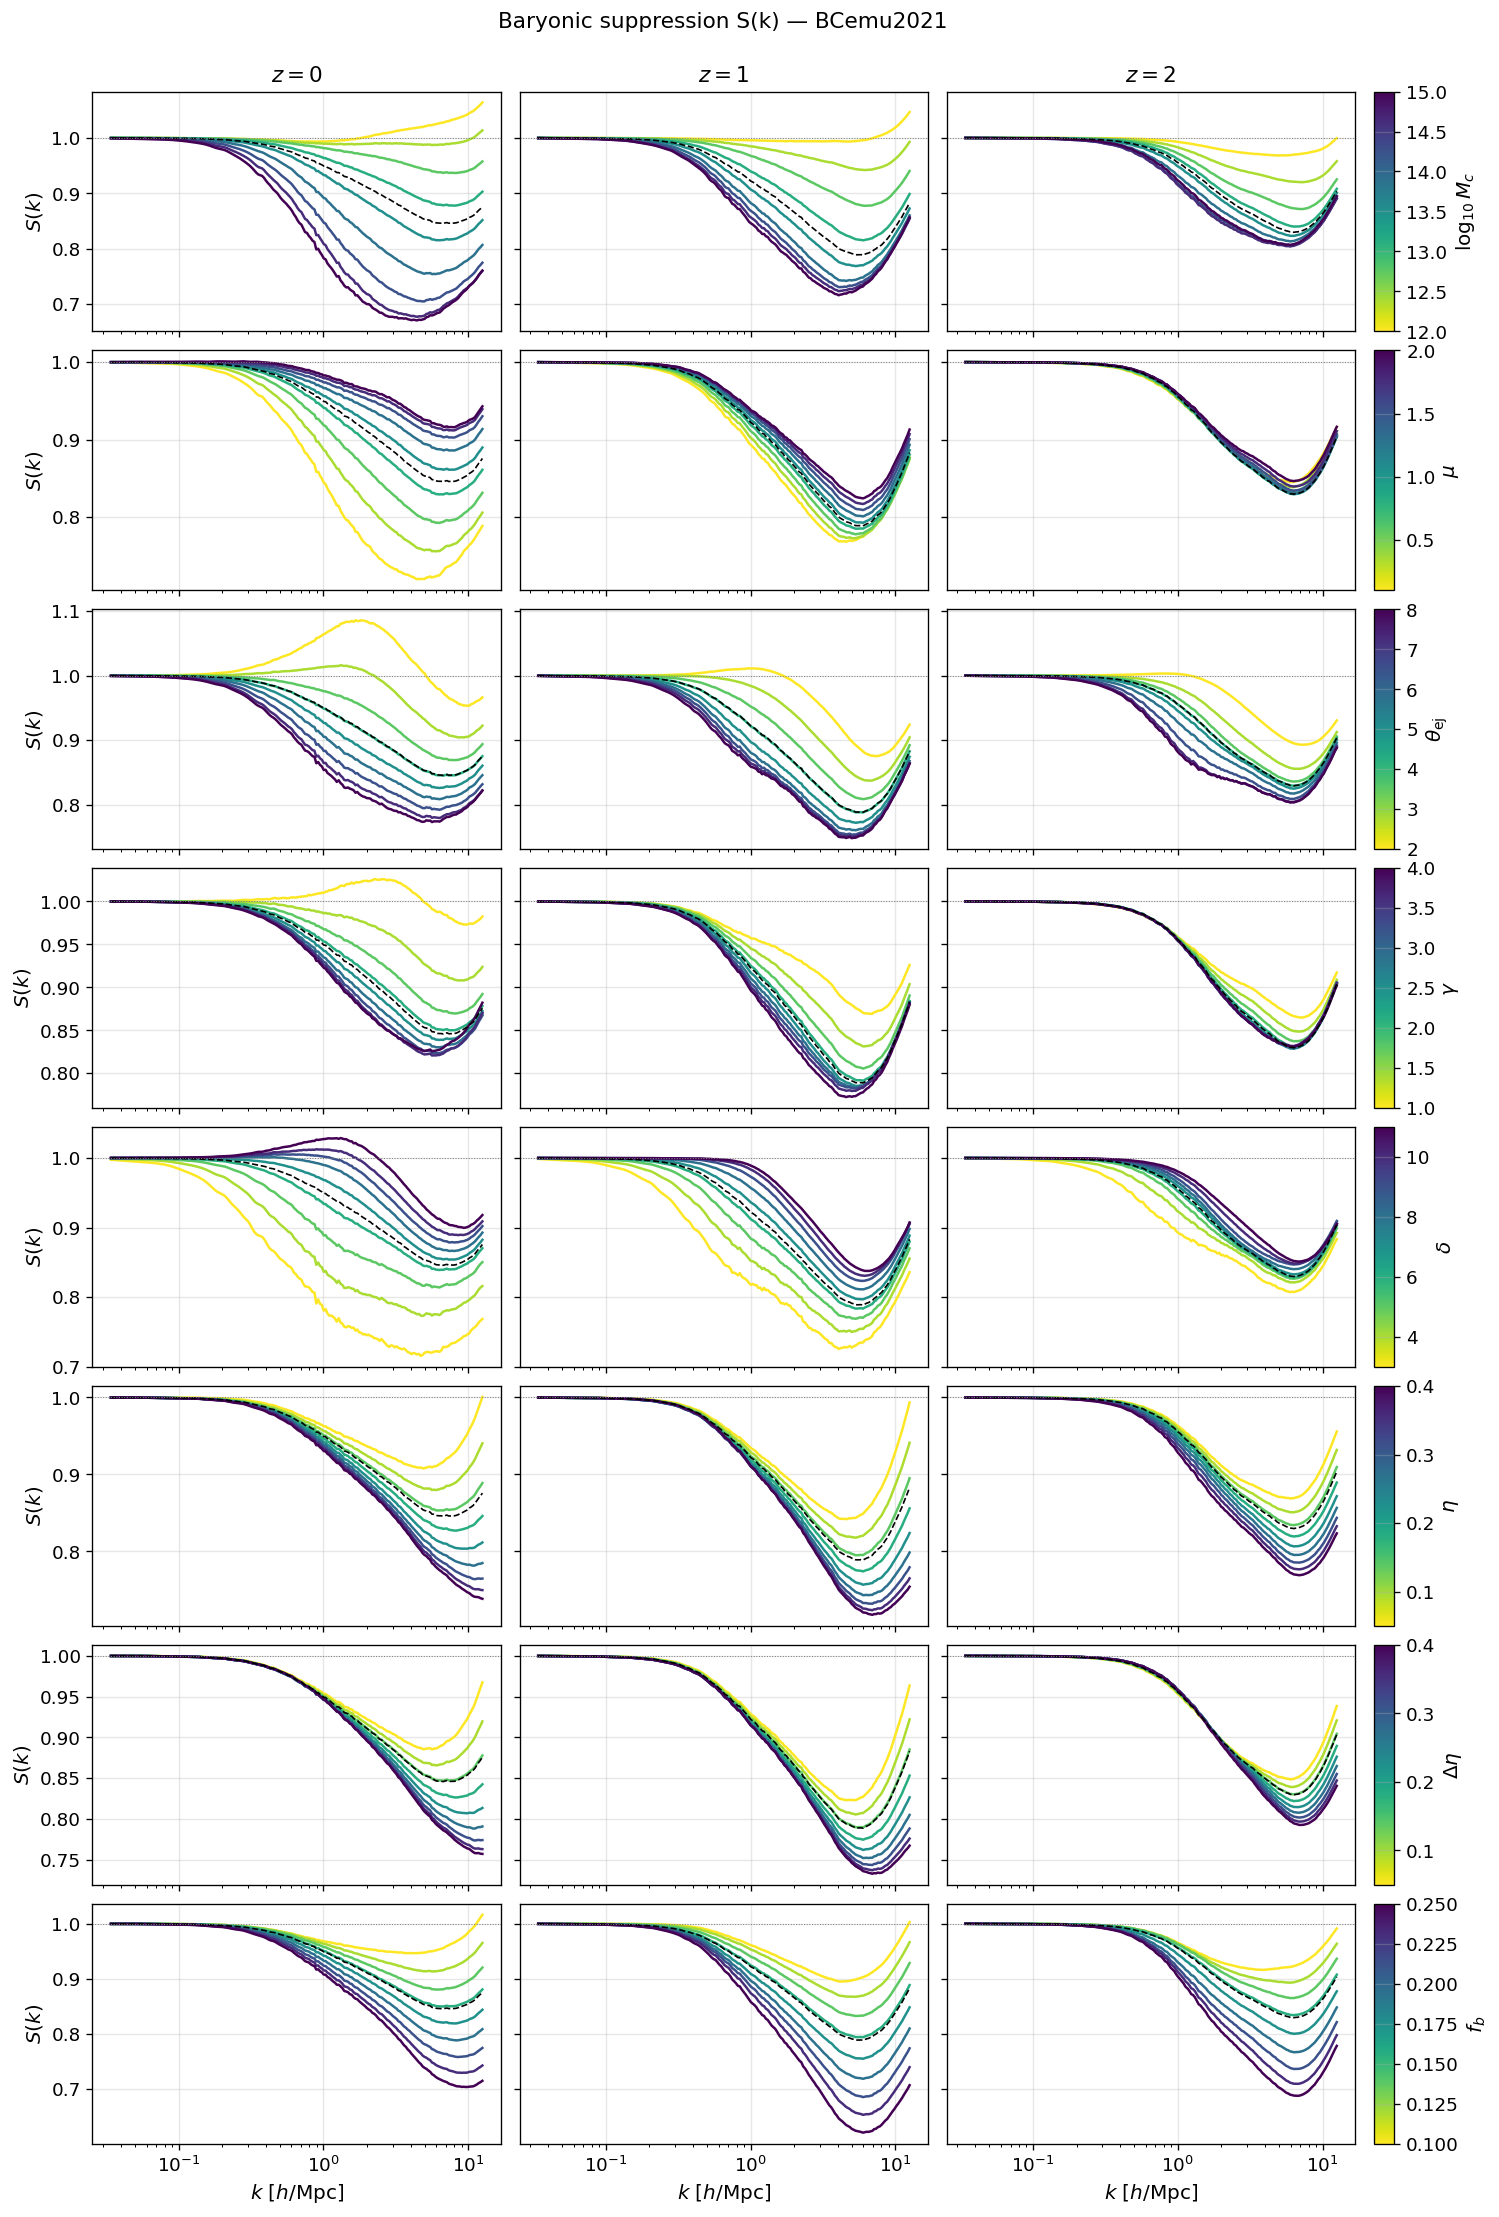

In [4]:
plot_param_sweep(Sk_2021, BCM2021_FID, PARAM_RANGES_2021, PARAM_LATEX_2021,
                 k2021, CMAP_2021, 'Baryonic suppression S(k) — BCemu2021')

---
## 2. BCemu2025

Eight-parameter emulator, trained on a $(z, q_2)$ grid; values at $z = 1, 2$
are interpolated between the neighbouring grid redshifts. $q_2 = 0.70$ is used
throughout.

In [5]:
CMAP_2025 = 'plasma_r'
Q2        = 0.70

emu2025 = BCemu.BCemu2025()
k2025   = emu2025.k   # h/Mpc

BCM2025_FID = {
    'Theta_co': 0.3, 'log10Mc': 13.1, 'mu': 1.0,
    'delta': 5.0,   'eta': 0.10,     'deta': 0.22,
    'Nstar': 0.028, 'fb': Ob / Om,
}

PARAM_RANGES_2025 = {
    'log10Mc':  (12.0, 14.5),
    'Theta_co': (0.05, 0.60),
    'mu':       (0.0,  2.5),
    'delta':    (3.0,  10.0),
    'eta':      (0.0,  0.5),
    'deta':     (0.0,  0.5),
    'Nstar':    (0.01, 0.15),
    'fb':       (0.08, 0.22),
}

PARAM_LATEX_2025 = {
    'log10Mc':  r'$\log_{10} M_c$',
    'Theta_co': r'$\Theta_{\rm co}$',
    'mu':       r'$\mu$',
    'delta':    r'$\delta$',
    'eta':      r'$\eta$',
    'deta':     r'$\Delta\eta$',
    'Nstar':    r'$N_\star$',
    'fb':       r'$f_b$',
}

def Sk_2025(params, z):
    return emu2025.get_boost(params, z=z, q2=Q2)[1]

Loading BCemu2025 models (backend='numpy')...


Loading model weights: 100%|██████████| 21/21 [00:00<00:00, 626.12it/s]

...BCemu2025 emulator is ready.


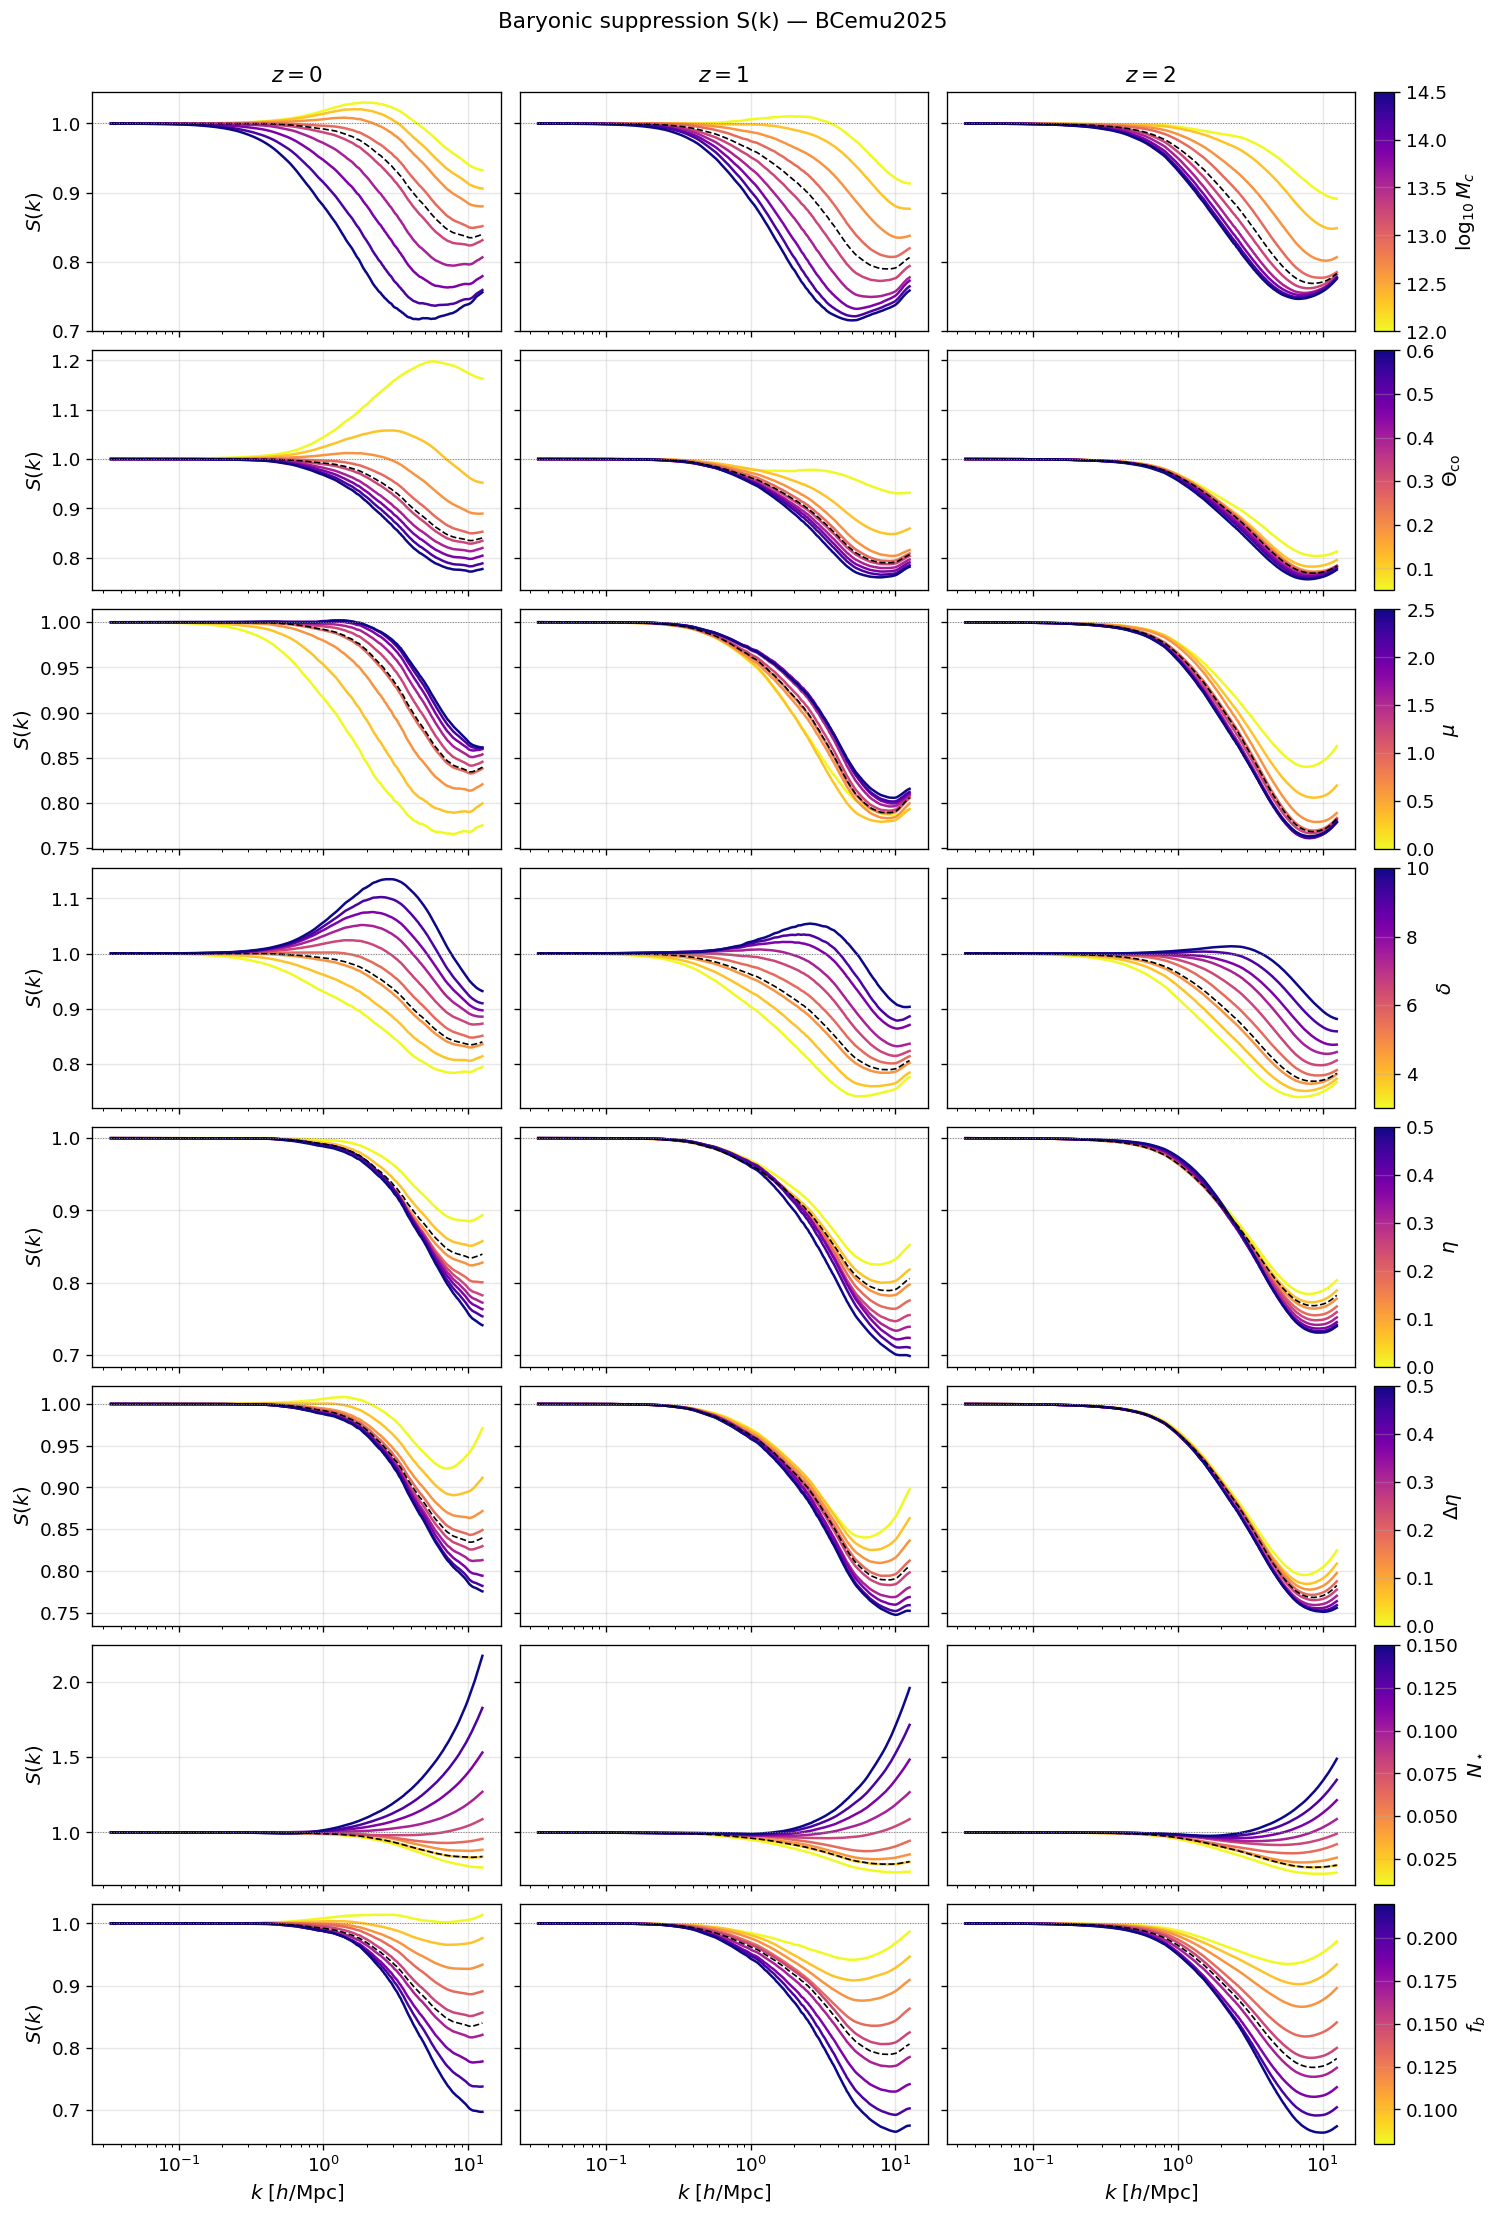

In [6]:
plot_param_sweep(Sk_2025, BCM2025_FID, PARAM_RANGES_2025, PARAM_LATEX_2025,
                 k2025, CMAP_2025, 'Baryonic suppression S(k) — BCemu2025')